<a href="https://colab.research.google.com/github/albasovatg-alt/Dataset-analysis/blob/main/%D0%98%D0%A6%D0%9F%D0%92%D0%B8%D0%B7%D1%83%D0%B0%D0%BB%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ссылка на датасет:
https://www.kaggle.com/datasets/ssssws/chocolate-sales-dataset-2023-2024

# 1) Загрузка и первичная обработка данных

In [ ]:
import os
import pandas as pd
import numpy as np
import kagglehub

In [ ]:
path = kagglehub.dataset_download("ssssws/chocolate-sales-dataset-2023-2024")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chocolate-sales-dataset-2023-2024' dataset.
Path to dataset files: /kaggle/input/chocolate-sales-dataset-2023-2024


In [ ]:
!ls /root/.cache/kagglehub/datasets/ssssws/chocolate-sales-dataset-2023-2024/versions/2 # смотрим где таблицы

calendar.csv  customers.csv  products.csv  sales.csv  stores.csv


In [ ]:
sales     = pd.read_csv("/kaggle/input/chocolate-sales-dataset-2023-2024/sales.csv") # делаем так, потому что много таблиц
products  = pd.read_csv("/kaggle/input/chocolate-sales-dataset-2023-2024/products.csv")
stores    = pd.read_csv("/kaggle/input/chocolate-sales-dataset-2023-2024/stores.csv")
customers = pd.read_csv("/kaggle/input/chocolate-sales-dataset-2023-2024/customers.csv")
calendar  = pd.read_csv("/kaggle/input/chocolate-sales-dataset-2023-2024/calendar.csv")

In [ ]:
df = sales.merge(products,  on="product_id",  how="left") \
          .merge(stores,    on="store_id",    how="left") \
          .merge(customers, on="customer_id", how="left") \
          .merge(calendar,  left_on="order_date", right_on="date", how="left") # объединяем их

Вывести первые и последние строки таблицы

In [ ]:
df.head(2) # первые 2 строки

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,...,age,gender,loyalty_member,join_date,date,year,month,day,week,day_of_week
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,...,44,Male,1,2021-11-17,2023-01-07,2023,1,7,1,5
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,...,63,Female,1,2023-07-03,2023-10-22,2023,10,22,42,6


In [ ]:
df.tail(2) # последние 2 строки

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,...,age,gender,loyalty_member,join_date,date,year,month,day,week,day_of_week
999998,0RD00999999,2024-01-03,P0090,S083,C042525,1,4.90,0.0,4.90,2.56,...,52,Male,0,2021-12-25,2024-01-03,2024,1,3,1,2
999999,0RD01000000,2024-04-10,P0175,S090,C025078,1,7.35,0.1,6.62,3.33,...,64,Male,0,2022-10-05,2024-04-10,2024,4,10,15,2


Определить: Размер датасета (количество строк и столбцов); Типы данных; Наличие пропущенных значений

In [ ]:
df.shape # размер датасета

(1000000, 30)

In [ ]:
df.info() # типы данных

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 30 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   order_id        1000000 non-null  object 
 1   order_date      1000000 non-null  object 
 2   product_id      1000000 non-null  object 
 3   store_id        1000000 non-null  object 
 4   customer_id     1000000 non-null  object 
 5   quantity        1000000 non-null  int64  
 6   unit_price      1000000 non-null  float64
 7   discount        1000000 non-null  float64
 8   revenue         1000000 non-null  float64
 9   cost            1000000 non-null  float64
 10  profit          1000000 non-null  float64
 11  product_name    990236 non-null   object 
 12  brand           990236 non-null   object 
 13  category        990236 non-null   object 
 14  cocoa_percent   990236 non-null   float64
 15  weight_g        990236 non-null   float64
 16  store_name      1000000 non-null  obj

In [ ]:
df.isna().sum().sum() # пропущенные значения

np.int64(48820)

# 2) Очистка данных

In [ ]:
na_sum = df.isna().sum().reset_index().rename(columns={0: 'count', 'index': 'column'}) # переименовываем, чтобы было видно в каком столбце сколько пропусков
na_sum = na_sum[na_sum['count'] > 0]
100 * (na_sum['count'] / df.shape[0]) # перевод в проценты

,count
11,0.9764
12,0.9764
13,0.9764
14,0.9764
15,0.9764


In [ ]:
df.isna().sum()

,0
order_id,0
order_date,0
product_id,0
store_id,0
customer_id,0
quantity,0
unit_price,0
discount,0
revenue,0
cost,0


In [ ]:
df["product_name"] = df["product_name"].fillna("Unknown product") # здесь меняем на unknown потому что категориальные данные
df["brand"]        = df["brand"].fillna("Unknown brand")
df["category"]     = df["category"].fillna("Unknown category")

In [ ]:
df["cocoa_percent"] = df["cocoa_percent"].fillna(df["cocoa_percent"].median()) # меняем на медиану, потому что это числовые данные
df["weight_g"]      = df["weight_g"].fillna(df["weight_g"].median())

In [ ]:
df.isna().sum() # проверка на наличие дубликатов

,0
order_id,0
order_date,0
product_id,0
store_id,0
customer_id,0
quantity,0
unit_price,0
discount,0
revenue,0
cost,0


# 3) Базовый анализ данных

In [ ]:
df.mean(numeric_only=True) # средние значения в числовых столбцах

,0
quantity,2.999589
unit_price,9.002449
discount,0.056248
revenue,25.486129
cost,15.291554
profit,10.194565
cocoa_percent,69.156450
weight_g,107.358840
age,44.044222
loyalty_member,0.501898


In [ ]:
num_cols = ["quantity", "unit_price", "discount", "revenue", "cost", "profit"] # отбираем числовые столбцы, находим медиану, мин., макс., станд., отклонение
for col in num_cols:
    print(f"\n{col}:")
    print("Медиана:", df[col].median())
    print("Минимум:", df[col].min())
    print("Максимум:", df[col].max())
    print("Стандартное отклонение:", df[col].std())


quantity:
Медиана: 3.0
Минимум: 1
Максимум: 5
Стандартное отклонение: 1.4136211760631672

unit_price:
Медиана: 9.01
Минимум: 3.0
Максимум: 15.0
Стандартное отклонение: 3.46290192299603

discount:
Медиана: 0.0
Минимум: 0.0
Максимум: 0.2
Стандартное отклонение: 0.07680877404262111

revenue:
Медиана: 21.92
Минимум: 2.4
Максимум: 75.0
Стандартное отклонение: 16.367863792469883

cost:
Медиана: 13.03
Минимум: 1.2
Максимум: 52.43
Стандартное отклонение: 9.972706198234734

profit:
Медиана: 8.6
Минимум: 0.73
Максимум: 37.43
Стандартное отклонение: 6.778760391166545


In [ ]:
print("Баланс классов по category (шт.):") # определяем баланс
print(df["category"].value_counts())
print("\nБаланс классов по category (%):")
print(df["category"].value_counts(normalize=True) * 100)

print("Баланс классов по brand (шт., топ-10):")
print(df["brand"].value_counts().head(10))
print("\nБаланс классов по brand (% , топ-10):")
print(df["brand"].value_counts(normalize=True).head(10) * 100)

print("Баланс классов по country (шт., топ-10):")
print(df["country"].value_counts().head(10))
print("\nБаланс классов по country (% , топ-10):")
print(df["country"].value_counts(normalize=True).head(10) * 100)

Баланс классов по category (шт.):
category
Praline             261678
White               238513
Dark                207727
Truffle             153729
Milk                128589
Unknown category      9764
Name: count, dtype: int64

Баланс классов по category (%):
category
Praline             26.1678
White               23.8513
Dark                20.7727
Truffle             15.3729
Milk                12.8589
Unknown category     0.9764
Name: proportion, dtype: float64
Баланс классов по brand (шт., топ-10):
brand
Ferrero          183603
Cadbury          183230
Lindt            173163
Mars             163441
Godiva           148973
Hershey          137826
Unknown brand      9764
Name: count, dtype: int64

Баланс классов по brand (% , топ-10):
brand
Ferrero          18.3603
Cadbury          18.3230
Lindt            17.3163
Mars             16.3441
Godiva           14.8973
Hershey          13.7826
Unknown brand     0.9764
Name: proportion, dtype: float64
Баланс классов по country (шт., то

In [ ]:
country_sales = df.groupby("country")["revenue"].sum().sort_values(ascending=False) # группировка (выручка по странам)
country_sales.head()

,revenue
country,
Canada,5085319.05
UK,4823617.98
USA,4341494.26
France,4339730.90
Australia,3834803.40


In [ ]:
categorical_cols = df.select_dtypes(include=["object", "string"]).columns # Наиболее часто встречающиеся категории
for col in categorical_cols:
    most_common = df[col].mode()[0]
    freq = df[col].value_counts(normalize=True).iloc[0] * 100
    print(f"{col}: {most_common} ({freq:.1f}%)")

order_id: 0RD00000001 (0.0%)
order_date: 2023-06-10 (0.1%)
product_id: P0021 (0.5%)
store_id: S013 (1.0%)
customer_id: C044952 (0.0%)
product_name: Dark Chocolate 50% (7.0%)
brand: Ferrero (18.4%)
category: Praline (26.2%)
store_name: Chocolate Store 13 (1.0%)
city: Toronto (18.0%)
country: Canada (20.0%)
store_type: Airport (29.9%)
gender: Male (50.4%)
join_date: 2025-11-03 (0.1%)
date: 2023-06-10 (0.1%)


In [ ]:
top5_category_revenue = (
    df.groupby("category")["revenue"]   # сгруппировать по типу шоколада
      .sum()                            # посчитать суммарную выручку
      .sort_values(ascending=False)     # отсортировать по убыванию
      .head(5)                          # взять топ-5
)

print(top5_category_revenue)

category
Praline    6665641.32
White      6070172.20
Dark       5298123.27
Truffle    3924343.24
Milk       3280368.19
Name: revenue, dtype: float64


# 4) Сформулировать вывод о наборе данных

Какие столбцы наиболее важные?

1.	Ключевые метрики продаж
Quantity_Sold, Unit_Price, Total_Revenue — основа для анализа выручки, маржи и прибыльности товаров и сегментов.
Discount / промо поля — позволяют оценить влияние акций на объём продаж и доход.
2.	Продуктовые характеристики
Product_ID, Product_Name, Category, Brand — описывают ассортимент, дают возможность искать лидеров и аутсайдеров по выручке и объёму.
Атрибуты типа вида шоколада (dark/milk/white), вкуса или упаковки помогают понять предпочтения клиентов и оптимизировать продуктовую линейку.
3.	Клиентские и демографические признаки
Customer_ID, Gender, Age_Group — используются для сегментации покупателей и поиска самых ценных сегментов по выручке и частоте покупок.
Анализ этих полей показывает, какие группы чаще покупают определённые категории и бренды, и где есть потенциал для таргетированных кампаний.


Какие закономерности можно выявить без применения методов машинного обучения?

1. Топ товаров и брендов
Топ 5 категорий, брендов и конкретных продуктов по выручке и количеству продаж: кто даёт основную долю оборота.
Доля каждой категории/бренда в общей выручке и объёме.
2. Влияние скидок и акций
Связь между размером скидки и ростом количества проданных единиц (группировки по диапазонам скидок).
Сравнение средней выручки и маржи по товарам с промо и без промо — бывают случаи, когда скидка увеличивает объём, но не окупает падение цены.
3. Сезонность
Тренд продаж по месяцам и неделям: всплески перед праздниками и провалы в «непраздничные» периоды.
Сравнение средней выручки по дням недели: выходные/будни, пиковые дни перед праздниками.

# 5) Визуализация

## 1. Построить гистограммы (распределение числового признака) для двух числовых столбцов.

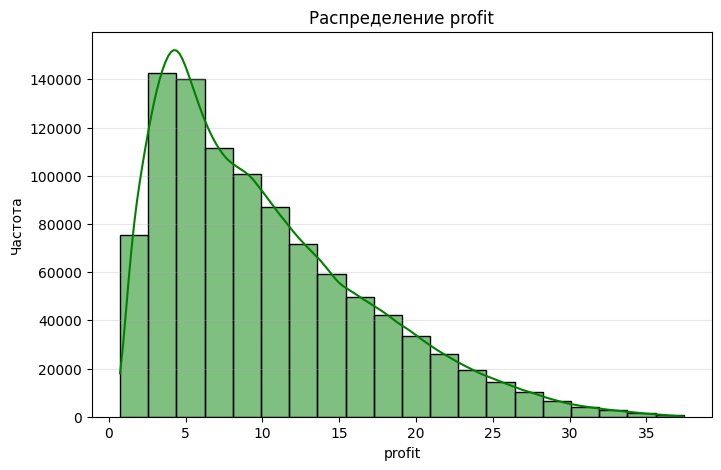

In [ ]:
import matplotlib.pyplot as plt     # библиотека для построения графиков
import seaborn as sns               # библиотека для гистограмм и т. п.
plt.figure(figsize=(8, 5))
sns.histplot(df['profit'], bins=20, kde=True, color='green')  # строим гистограмму
plt.title('Распределение profit')
plt.xlabel('profit')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.3)  # добавляем сетку
plt.show()

По гистограмме profit можно увидеть, какие значения прибыли встречаются чаще всего, есть ли сильный разброс и имеются ли редкие большие или маленькие значения.

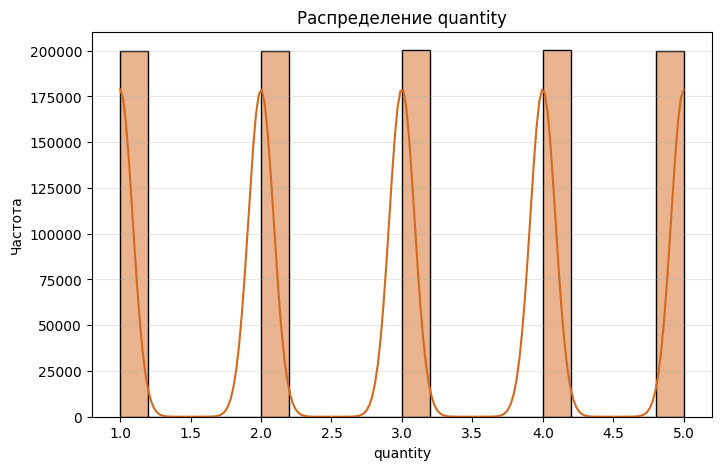

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['quantity'], bins=20, kde=True, color='chocolate')
plt.title('Распределение quantity')
plt.xlabel('quantity')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.3)
plt.show()

По гистограмме quantity можно увидеть, какие значения количества продаж встречаются чаще всего, насколько сильно они разбросаны и есть ли редкие большие значения.

## 2. Построить столбчатую диаграмму для категориального признака.

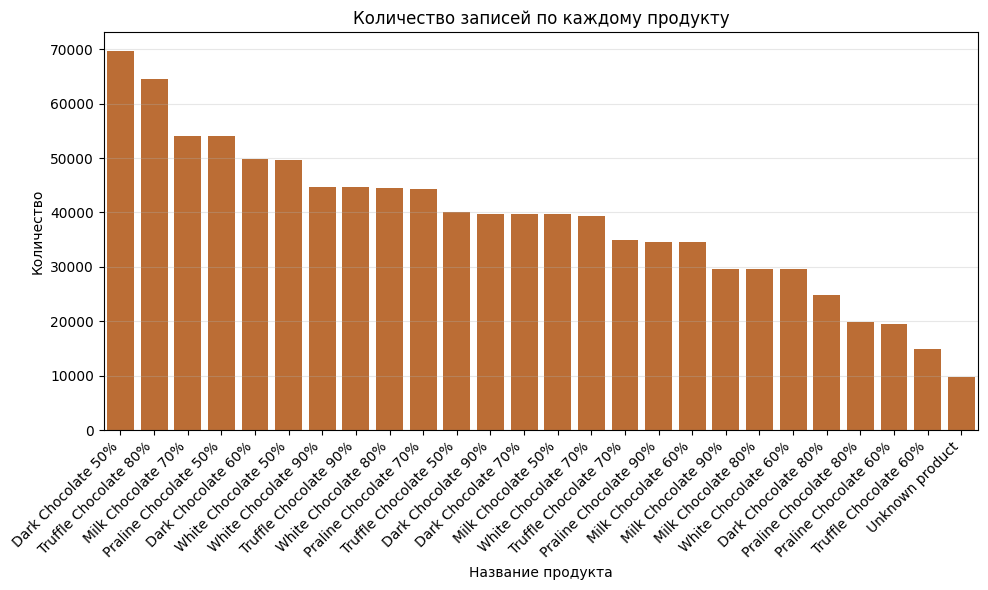

In [ ]:
product_counts = df['product_name'].value_counts()  # считаем, сколько раз каждый продукт встречается в датасете
plt.figure(figsize=(10, 6))
sns.barplot(x=product_counts.index, y=product_counts.values, color='chocolate')
plt.title('Количество записей по каждому продукту')
plt.xlabel('Название продукта')
plt.ylabel('Количество')
plt.xticks(rotation=45, ha='right')                 # поворачиваем подписи по оси X
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

По диаграмме видно, какие продукты встречаются в датасете чаще всего, а какие - реже. Это помогает понять, какие категории товаров наиболее представлены в данных.

# 3. Построить круговую диаграмму для категориального признака

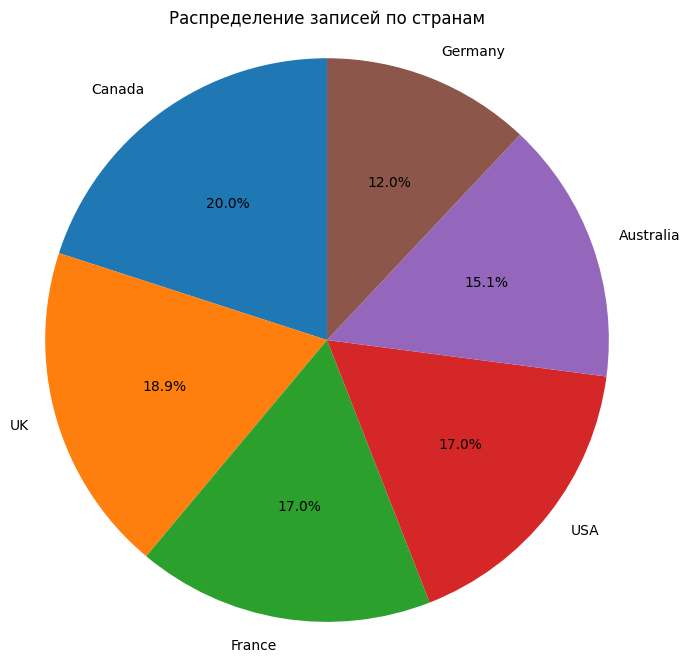

In [ ]:
country_counts = df['country'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(country_counts.values, labels=country_counts.index, autopct='%1.1f%%', startangle=90)  # строим круговую диаграмму с процентами
plt.title('Распределение записей по странам')
plt.axis('equal')  # делаем круг
plt.show()

Диаграмма показывает, какие страны занимают наибольшую долю в датасете, а какие представлены меньше всего. Это помогает увидеть, в каких странах совершается больше покупок и из каких стран поступает больше записей

# 4. Построить линейный график для любого признака => отобразить динамику

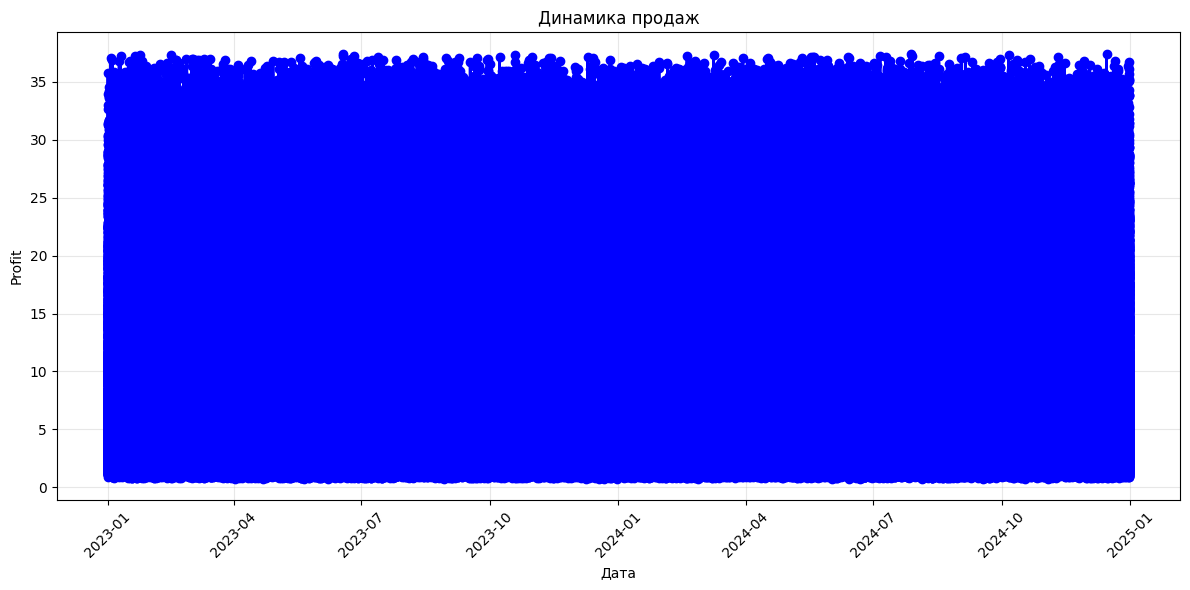

In [ ]:
df['date'] = pd.to_datetime(df['date'])
df_sorted = df.sort_values('date')  # сортируем данные по дате
plt.figure(figsize=(12, 6))
plt.plot(df_sorted['date'], df_sorted['revenue'], color='blue', marker='o', linewidth=2)  # строим линейный график выручки по датам
plt.title('Динамика продаж')
plt.xlabel('Дата')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

График показывает, как менялись продажи со временем, это помогает оценить общую динамику продаж в датасете.

# 5. Построить сравнительную столбчатую диаграмму для нескольких признаков (признаки должны быть измеримы по одной шкале, например: оценки, деньги в одной валюте и др).

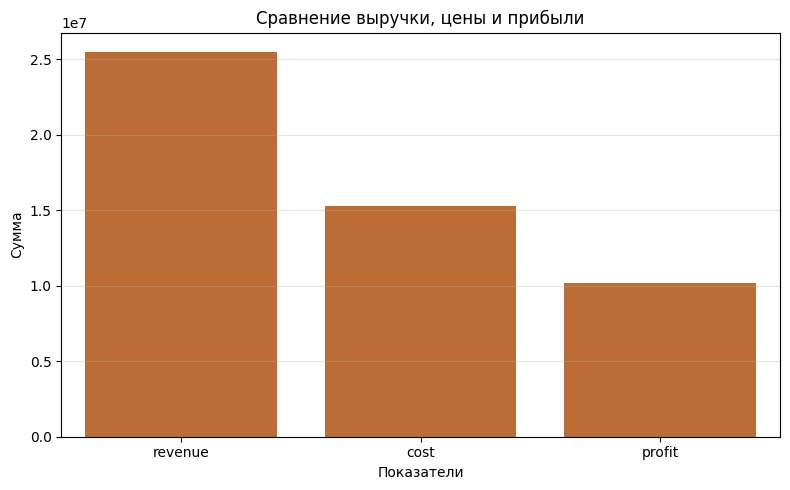

In [ ]:
metrics = ['revenue', 'cost', 'profit']
values = [df['revenue'].sum(), df['cost'].sum(), df['profit'].sum()] # считаем общие значения по каждому признаку, чтобы сравнить их по одной шкале
plt.figure(figsize=(8, 5))
sns.barplot(x=metrics, y=values, color='chocolate')       # строим сравнительную столбчатую диаграмму
plt.title('Сравнение выручки, цены и прибыли')
plt.xlabel('Показатели')
plt.ylabel('Сумма')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Диаграмма показывает, какой из показателей имеет наибольшее значение и насколько сильно они отличаются друг от друга.